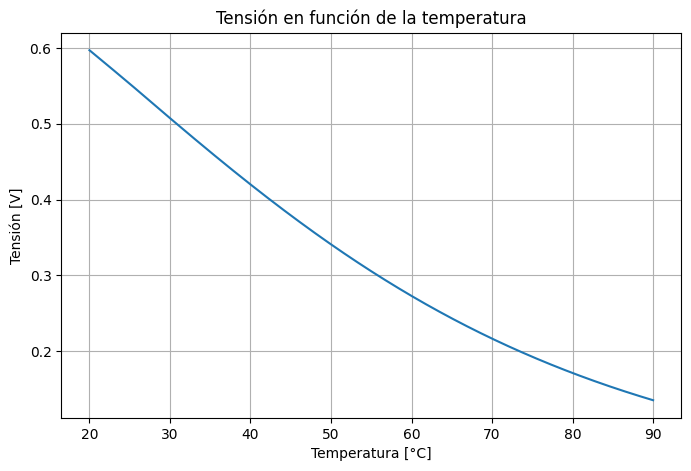

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos salteando la primera fila
datos = np.loadtxt("datos_simulacion.txt", skiprows=1)

# Separar columnas
temperatura = datos[:, 0]
tension = datos[:, 1]

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(temperatura, tension)

# Etiquetas y título
plt.xlabel("Temperatura [°C]")
plt.ylabel("Tensión [V]")
plt.title("Tensión en función de la temperatura")

# Grilla
plt.grid(True)

plt.savefig("Tension_vs_temp.pdf", format="pdf")

# Mostrar gráfico
plt.show()


Beta   = 3437.79 K
R298   = 10056.79 ohms
E_gap  = 0.5925 eV


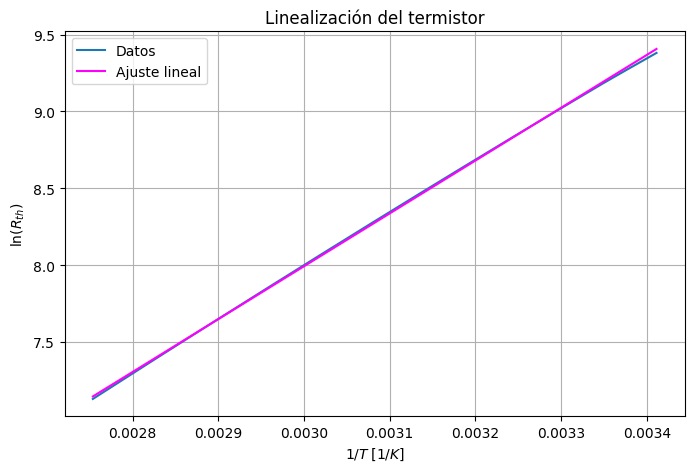

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# Cargar datos
# =====================================

datos = np.loadtxt("datos_simulacion.txt", skiprows=1)

temperatura_C = datos[:, 0]
V = datos[:, 1]

# =====================================
# Constantes del circuito
# =====================================

Vcc = 1.0          # volts
Rf = 8000          # ohms

# =====================================
# Reconstruir resistencia del termistor
# =====================================

Rth = Rf * V / (Vcc - V)

# =====================================
# Temperatura en Kelvin
# =====================================

T = temperatura_C + 273.15

# =====================================
# Linealización
# ln(R) = beta*(1/T) + b
# =====================================

x = 1 / T
y = np.log(Rth)

# Ajuste lineal
beta, b = np.polyfit(x, y, 1)

# =====================================
# Calcular R298
# =====================================

R298 = np.exp(b + beta / 298)

# =====================================
# Calcular E_gap
# beta = Eg / (2k)
# => Eg = 2 k beta
# =====================================

k_B = 8.617333262e-5   # eV/K

E_gap = 2 * k_B * beta

# =====================================
# Recta ajustada
# =====================================

y_fit = beta * x + b

# =====================================
# Mostrar resultados
# =====================================

print(f"Beta   = {beta:.2f} K")
print(f"R298   = {R298:.2f} ohms")
print(f"E_gap  = {E_gap:.4f} eV")

# =====================================
# Gráfico
# =====================================

plt.figure(figsize=(8,5))

plt.plot(x, y, label="Datos")
plt.plot(x, y_fit, label="Ajuste lineal", color = "magenta")

plt.xlabel(r"$1/T \; [1/K]$")
plt.ylabel(r"$\ln(R_{th})$")
plt.title("Linealización del termistor")

plt.grid(True)
plt.legend()

plt.savefig("linealizacion_y_ajuste.pdf", format="pdf")

plt.show()

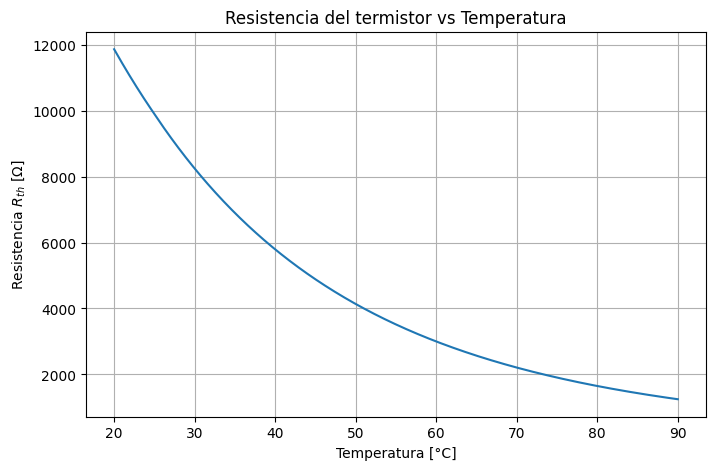

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# Cargar datos
# =====================================

datos = np.loadtxt("datos_simulacion.txt", skiprows=1)

temperatura_C = datos[:, 0]
V = datos[:, 1]

# =====================================
# Constantes del circuito
# =====================================

Vcc = 1.0          # volts
Rf = 8000          # ohms

# =====================================
# Calcular resistencia del termistor
# =====================================

Rth = Rf * V / (Vcc - V)

# =====================================
# Gráfico R vs T
# =====================================

plt.figure(figsize=(8,5))

plt.plot(temperatura_C, Rth)

plt.xlabel("Temperatura [°C]")
plt.ylabel(r"Resistencia $R_{th}$ [$\Omega$]")
plt.title("Resistencia del termistor vs Temperatura")

plt.grid(True)

plt.savefig("R_vs_T.pdf", format="pdf")

plt.show()